In [72]:
from typing import TypedDict,Annotated,List,Literal
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage,SystemMessage,HumanMessage,AIMessage

from langgraph.graph import StateGraph,START,END
from langgraph.types import Send
from langgraph.checkpoint.memory import InMemorySaver

from typing import TypedDict
from pydantic import BaseModel,Field
import operator

from dotenv import load_dotenv
from pathlib import Path

import uuid

load_dotenv()


True

In [60]:
model=ChatOpenAI(model='gpt-4.1-mini')

In [61]:
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=5,
        description="3–5 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(
        ...,
        description="Target word count for this section (120–450).",
    )
    section_type: Literal[
        "intro", "core", "examples", "checklist", "common_mistakes", "conclusion"
    ] = Field(
        ...,
        description="Use 'common_mistakes' exactly once in the plan.",
    )

In [62]:
class Plan(BaseModel):
    blog_title:str
    audience: str = Field(..., description="Who this blog is for.")
    tone: str = Field(..., description="Writing tone (e.g., practical, crisp).")
    tasks: List[Task]

In [63]:
class BlogAgentState(TypedDict):
    topic:str
    plan:Plan
    sections:Annotated[List[str],operator.add]
    blog:str

In [64]:
def orchestrator(state:BlogAgentState):
    planner=model.with_structured_output(Plan)
    
    plan = planner.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    
    return {'plan':plan}

# this is a routing function which creates multiple worker for each of the task which are executed parallelyy
def fanout(state: BlogAgentState):
    return [
        Send(
            'worker',
            {'task':task, 'topic':state['topic'], 'plan':state['plan']}
        )
        for task in state['plan'].tasks
    ]



def worker(state: dict) -> dict:
    task = state["task"]
    topic = state["topic"]
    plan = state["plan"]

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    section_md = model.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior technical writer and developer advocate. "
                    "Write ONE section of a technical blog post in Markdown.\n\n"

                    "Hard constraints:\n"
                    "- Follow the provided Goal and cover ALL Bullets in order "
                    "(do not skip or merge bullets).\n"
                    "- Stay close to the Target words (±15%).\n"
                    "- Output ONLY the section content in Markdown "
                    "(no blog title H1, no extra commentary).\n\n"

                    "Technical quality bar:\n"
                    "- Be precise and implementation-oriented (developers should be able to apply it).\n"
                    "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
                    "- When relevant, include at least one of:\n"
                    "  * a small code snippet (minimal, correct, and idiomatic)\n"
                    "  * a tiny example input/output\n"
                    "  * a checklist of steps\n"
                    "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
                    "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
                    "- Call out edge cases / failure modes and what to do about them.\n"
                    "- If you mention a best practice, add the 'why' in one sentence.\n\n"

                    "Markdown style:\n"
                    "- Start with a '## <Section Title>' heading.\n"
                    "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
                    "- Avoid fluff. Avoid marketing language.\n"
                    "- If you include code, keep it focused on the bullet being addressed.\n"
                )
            ),
            HumanMessage(
                content=(
                    f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"

                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {
        "sections": [section_md]
    }
    

def reducer(state: BlogAgentState) -> dict:

    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()
    
    final_md = f"# {title}\n\n{body}\n"

    # Save to file
    filename = "".join(c if c.isalnum() or c in (" ", "_", "-") else "" for c in title)
    filename = filename.strip().lower().replace(" ", "_") + ".md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"blog": final_md}

In [67]:
graph=StateGraph(state_schema=BlogAgentState)
checkpoint=InMemorySaver()

graph.add_node('orchestrator',orchestrator)
graph.add_node('worker',worker)
graph.add_node('reducer',reducer)

graph.add_edge(START,'orchestrator')
graph.add_conditional_edges("orchestrator", fanout, ["worker"])
graph.add_edge('worker','reducer')
graph.add_edge('reducer',END)

workflow=graph.compile(checkpointer=checkpoint)

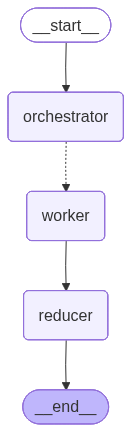

In [68]:
workflow

In [ ]:
config={'configurable':{"thread_id":str(uuid.uuid4())}}

response=workflow.invoke({"topic": "Write a blog on how someone with basic coding skills can start with GenAI and become an AI engineer. Include a roadmap, tools, and learning resources.", "sections": []},config=config)

Deserializing unregistered type __main__.Plan from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Plan')]


In [70]:
print(response)

{'topic': 'Write a blog on Self Attention', 'plan': Plan(blog_title='Demystifying Self-Attention: From Fundamentals to Practical Implementation', audience='Developers and Machine Learning Engineers interested in understanding and implementing self-attention mechanisms in neural networks', tone='Practical and technical', tasks=[Task(id=1, title='Introduction to Self-Attention', goal='Understand what self-attention is and why it is pivotal in modern neural network architectures.', bullets=['Define self-attention and contrast it with traditional attention and other sequence processing methods.', 'Explain the problem self-attention solves, namely the need to capture dependencies regardless of position in sequences.', 'Outline common use cases like NLP, computer vision, and transformer models where self-attention excels.', 'Present a high-level overview of how self-attention computes weighted representations of input sequences automatically.', 'Include a simple diagram or pseudocode illustr